**A. Membangun Struktur Direktori HDFS**

In [6]:
!hdfs dfs -mkdir -p /user/xiuviu/ecommerce/raw
!hdfs dfs -mkdir -p /user/xiuviu/ecommerce/processed
!hdfs dfs -ls /user/xiuviu/ecommerce

Found 2 items
drwxr-xr-x   - xiuviu supergroup          0 2026-09-09 19:28 /user/xiuviu/ecommerce/processed
drwxr-xr-x   - xiuviu supergroup          0 2026-09-09 19:28 /user/xiuviu/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS**

In [7]:
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/xiuviu/ecommerce/raw
!hdfs dfs -ls -h /user/xiuviu/ecommerce/raw

Found 3 items
-rw-r--r--   1 xiuviu supergroup     12.0 K 2026-09-09 19:29 /user/xiuviu/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 xiuviu supergroup     11.9 K 2026-09-09 19:29 /user/xiuviu/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 xiuviu supergroup     12.4 K 2026-09-09 19:29 /user/xiuviu/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS**

In [8]:
!hdfs dfs -get /user/xiuviu/ecommerce/raw/transaksi_magelang.csv
!hdfs dfs -get /user/xiuviu/ecommerce/raw/transaksi_yogyakarta.csv
!hdfs dfs -get /user/xiuviu/ecommerce/raw/transaksi_semarang.csv

get: `transaksi_magelang.csv': File exists
get: `transaksi_yogyakarta.csv': File exists
get: `transaksi_semarang.csv': File exists


In [9]:
import pandas as pd

df_magelang = pd.read_csv("transaksi_magelang.csv")
df_yogyakarta = pd.read_csv("transaksi_yogyakarta.csv")S
df_semarang = pd.read_csv("transaksi_semarang.csv")

df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)
df_gabungan["kota"].value_counts()

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

**D. Mengolah dan Download Hasil ke Direktori `processed`**

In [12]:
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

ringkasan = df_gabungan.groupby(["kategori", "kota"])["total_pendapatan"].sum().reset_index()

df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

In [11]:
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/xiuviu/ecommerce/processed
!hdfs dfs -ls -h /user/xiuviu/ecommerce/processed

Found 2 items
-rw-r--r--   1 xiuviu supergroup     40.3 K 2026-09-09 19:29 /user/xiuviu/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 xiuviu supergroup        530 2026-09-09 19:29 /user/xiuviu/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi**

/user/xiuviu/ecommerce
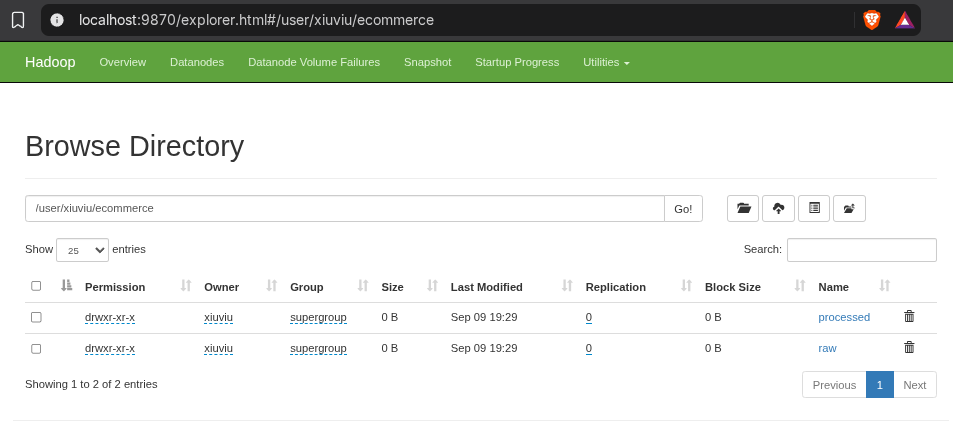
/user/xiuviu/ecommerce/processed
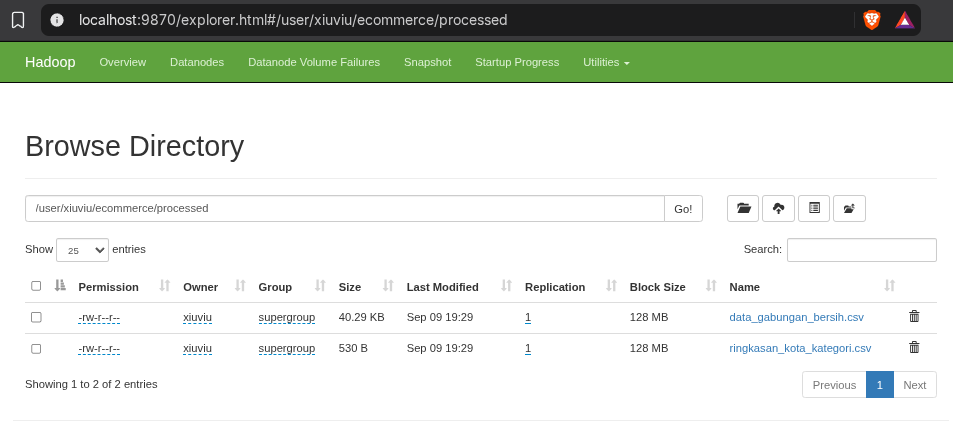
/user/xiuviu/ecommerce/raw
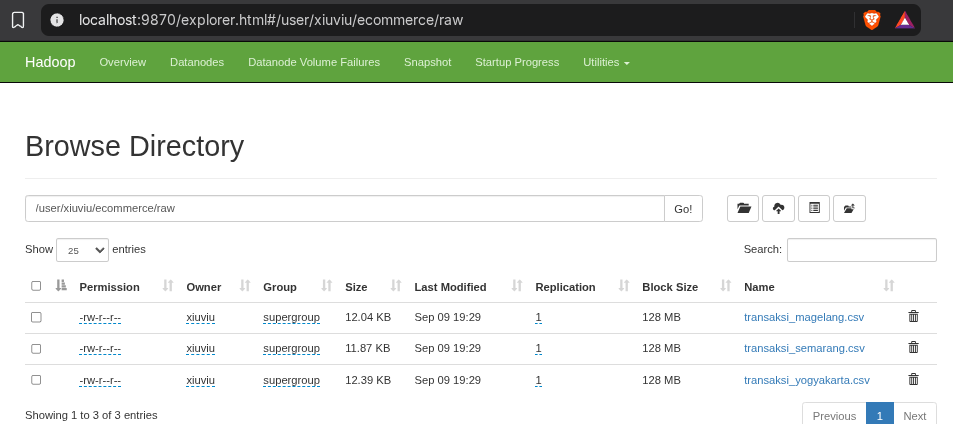

**Refleksi:**
Kalau data mentah dan data yang sudah diolah digabung dalam satu folder yang sama, lama-lama jadi susah dibedakan mana file asli dan mana hasil olahan, apalagi kalau prosesnya diulang berkali-kali. Dengan memisahkan folder `raw` dan `processed`, data asli di `raw` tetap utuh dan aman dijadikan acuan kalau sewaktu-waktu perlu diproses ulang, sementara folder `processed` bebas ditimpa atau dihapus tanpa risiko kehilangan data sumbernya.